# ESG Company Segmentation & Persona Classification

## Objective

This notebook builds an end-to-end unsupervised → supervised ML workflow:

1. Understand the financial and ESG dataset.
2. Define the correct **unit of analysis** for company segmentation.
3. Engineer features suitable for distance-based clustering.
4. Use **K-Means** to discover company personas without a target label.
5. Select the number of clusters using multiple diagnostics.
6. Profile and interpret the discovered clusters.
7. Define business-oriented persona names **after** inspecting the clusters.
8. Train a **Random Forest classifier** to reproduce the discovered segmentation for new companies.
9. Evaluate the classifier with appropriate classification metrics.
10. Inspect which features drive persona assignment.
11. Serialize the preprocessing + clustering + classification artifacts.

> **Important conceptual point:** K-Means is unsupervised, while the Random Forest is supervised. The classifier's target is not an original business truth; it is the cluster label generated by K-Means. Therefore, classifier accuracy measures how well the classifier reproduces the clustering rule, not whether the personas are objectively "correct".

## Business Problem

**Can we automatically discover different types of companies based on financial performance and ESG behavior, and then assign a new company to one of those discovered personas?**

Potential business use cases:

- investor screening
- ESG benchmarking
- identifying resource-intensive businesses
- comparing sustainable vs financially strong companies
- prioritizing companies for deeper due diligence

### Modeling strategy

**Historical company-year data → latest company snapshot → feature engineering → scaling → K-Means clustering → cluster interpretation → Random Forest surrogate classifier**

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    classification_report,
    confusion_matrix,
    accuracy_score
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
import joblib

RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)

In [2]:
from pathlib import Path

DATA_CANDIDATES = [
    Path("/mnt/data/company_esg_financial_dataset.csv"),
    Path("/content/company_esg_financial_dataset.csv"),
    Path("company_esg_financial_dataset.csv"),
]

DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError("company_esg_financial_dataset.csv not found.")

df = pd.read_csv(DATA_PATH)

print(f"Using dataset: {DATA_PATH}")
print(f"Shape: {df.shape}")
display(df.head())

Using dataset: /mnt/data/company_esg_financial_dataset.csv
Shape: (11000, 16)


,CompanyID,CompanyName,Industry,Region,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption
0,1,Company_1,Retail,Latin America,2015,459.2,6.0,337.5,NaN,57.0,60.7,33.5,76.8,35577.4,17788.7,71154.7
1,1,Company_1,Retail,Latin America,2016,473.8,4.6,366.6,3.2,56.7,58.9,32.8,78.5,37314.7,18657.4,74629.4
2,1,Company_1,Retail,Latin America,2017,564.9,5.2,313.4,19.2,56.5,57.6,34.0,77.8,45006.4,22503.2,90012.9
3,1,Company_1,Retail,Latin America,2018,558.4,4.3,283.0,-1.1,58.0,62.3,33.4,78.3,42650.1,21325.1,85300.2
4,1,Company_1,Retail,Latin America,2019,554.5,4.9,538.1,-0.7,56.6,63.7,30.0,76.1,41799.4,20899.7,83598.8


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CompanyID          11000 non-null  int64  
 1   CompanyName        11000 non-null  object 
 2   Industry           11000 non-null  object 
 3   Region             11000 non-null  object 
 4   Year               11000 non-null  int64  
 5   Revenue            11000 non-null  float64
 6   ProfitMargin       11000 non-null  float64
 7   MarketCap          11000 non-null  float64
 8   GrowthRate         10000 non-null  float64
 9   ESG_Overall        11000 non-null  float64
 10  ESG_Environmental  11000 non-null  float64
 11  ESG_Social         11000 non-null  float64
 12  ESG_Governance     11000 non-null  float64
 13  CarbonEmissions    11000 non-null  float64
 14  WaterUsage         11000 non-null  float64
 15  EnergyConsumption  11000 non-null  float64
dtypes: float64(11), int64(

In [4]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CompanyID,11000.0,NaN,NaN,NaN,500.5,288.688113,1.0,250.75,500.5,750.25,1000.0
CompanyName,11000,1000,Company_1,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Industry,11000,9,Healthcare,1331,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,11000,7,Asia,1672,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,11000.0,NaN,NaN,NaN,2020.0,3.162421,2015.0,2017.0,2020.0,2023.0,2025.0
Revenue,11000.0,NaN,NaN,NaN,4670.850591,9969.954369,35.9,938.775,1902.3,4342.625,180810.4
ProfitMargin,11000.0,NaN,NaN,NaN,10.900455,8.758711,-20.0,5.3,10.5,16.3,50.0
MarketCap,11000.0,NaN,NaN,NaN,13380.622236,39922.870373,1.8,1098.525,3096.45,9995.5,865271.7
GrowthRate,10000.0,NaN,NaN,NaN,4.83037,9.424787,-36.0,-1.325,4.9,11.0,38.0
ESG_Overall,11000.0,NaN,NaN,NaN,54.615273,15.893937,6.3,44.1,54.6,65.6,98.8


## 1. Data Quality

Before modeling, check:

- missing values
- duplicate records
- impossible values
- categorical cardinality
- whether each company has multiple yearly observations

The `GrowthRate` missing values are expected for the first reporting year because year-over-year growth cannot be calculated for the first observation.

In [5]:
quality = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_%": (df.isna().mean() * 100).round(2),
    "unique": df.nunique()
}).sort_values("missing", ascending=False)

display(quality)
print("Duplicate rows:", df.duplicated().sum())

,dtype,missing,missing_%,unique
GrowthRate,float64,1000,9.09,562
CompanyID,int64,0,0.00,1000
Industry,object,0,0.00,9
CompanyName,object,0,0.00,1000
Year,int64,0,0.00,11
Revenue,float64,0,0.00,9965
ProfitMargin,float64,0,0.00,536
Region,object,0,0.00,7
MarketCap,float64,0,0.00,10385
ESG_Overall,float64,0,0.00,823


Duplicate rows: 0


In [6]:
print("Companies:", df["CompanyID"].nunique())
print("Years:", sorted(df["Year"].unique()))
print("Industries:", df["Industry"].nunique())
print("Regions:", df["Region"].nunique())

display(df["Industry"].value_counts().rename("count").to_frame())
display(df["Region"].value_counts().rename("count").to_frame())

Companies: 1000
Years: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Industries: 9
Regions: 7


,count
Industry,
Healthcare,1331
Manufacturing,1287
Transportation,1287
Consumer Goods,1276
Finance,1243
Energy,1188
Utilities,1177
Retail,1166
Technology,1045


,count
Region,
Asia,1672
Oceania,1661
Middle East,1617
Europe,1540
North America,1540
Latin America,1507
Africa,1463


## 2. Decide the Unit of Analysis

This is one of the most important modeling decisions.

The dataset contains **1,000 companies observed over multiple years**. If we cluster all 11,000 company-year rows, the same company appears repeatedly and can dominate the segmentation.

Because the business question asks for **types of companies**, we use the **latest available year for each company** as the segmentation snapshot.

This gives approximately one row per company and makes the clustering interpretation much cleaner.

For a different business question—such as "how company behavior changes over time"—a company-year clustering design would be appropriate instead.

In [7]:
latest_year = df["Year"].max()

company_df = (
    df.sort_values(["CompanyID", "Year"])
      .groupby("CompanyID", as_index=False)
      .tail(1)
      .reset_index(drop=True)
)

print("Latest year used:", latest_year)
print("Company-level rows:", len(company_df))
print("Unique companies:", company_df["CompanyID"].nunique())

display(company_df.head())

Latest year used: 2025
Company-level rows: 1000
Unique companies: 1000


,CompanyID,CompanyName,Industry,Region,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption
0,1,Company_1,Retail,Latin America,2025,734.5,5.0,628.8,6.9,59.2,70.7,29.1,78.0,51805.8,25902.9,103611.7
1,2,Company_2,Retail,Asia,2025,4371.5,-2.4,20376.3,14.4,66.3,65.8,62.8,70.3,323282.0,161641.0,646564.1
2,3,Company_3,Transportation,Latin America,2025,479.8,11.6,1020.7,9.5,34.3,24.4,43.7,34.9,296242.0,49373.7,987473.3
3,4,Company_4,Technology,Africa,2025,7675.6,22.9,42400.4,17.1,64.1,100.0,65.4,27.0,191891.1,115134.7,383782.3
4,5,Company_5,Finance,Middle East,2025,3162.1,22.4,6674.6,-3.7,48.0,82.1,18.7,43.3,39561.3,19780.6,98903.2


In [8]:
assert company_df["CompanyID"].nunique() == len(company_df), "Company-level dataset must contain one row per company."
assert company_df["Year"].nunique() == 1, "Latest snapshot should contain one year."

company_df["GrowthRate"].isna().sum()

np.int64(0)

## 3. Feature Engineering

We intentionally exclude:

- `CompanyID`: identifier, not a business characteristic
- `CompanyName`: identifier
- `Year`: constant in the latest snapshot
- `Industry` and `Region`: categorical context, not used as clustering inputs

### Why log-transform?

Revenue, market capitalization, emissions, water usage and energy consumption are heavily right-skewed. K-Means relies on Euclidean distance, so extreme values can disproportionately influence the clusters.

`log1p(x)` compresses large values while preserving zero safely.

### Why standardize?

After log transformation, variables still have different units. Standardization gives each feature comparable variance before Euclidean-distance-based clustering.

In [9]:
cluster_features = [
    "Revenue",
    "ProfitMargin",
    "MarketCap",
    "GrowthRate",
    "ESG_Overall",
    "CarbonEmissions",
    "WaterUsage",
    "EnergyConsumption"
]

log_features = [
    "Revenue",
    "MarketCap",
    "CarbonEmissions",
    "WaterUsage",
    "EnergyConsumption"
]

model_df = company_df.copy()

# GrowthRate is expected to be missing only when the historical first year is retained.
# The latest snapshot should normally have a valid value, but keep this robust.
model_df["GrowthRate"] = model_df["GrowthRate"].fillna(
    model_df["GrowthRate"].median()
)

for col in log_features:
    model_df[col] = np.log1p(model_df[col])

display(model_df[cluster_features].describe().T)

,count,mean,std,min,25%,50%,75%,max
Revenue,1000.0,7.881151,1.258395,3.608212,6.996201,7.777520,8.730281,12.105210
ProfitMargin,1000.0,10.765400,10.264601,-20.000000,4.000000,10.300000,16.925000,50.000000
MarketCap,1000.0,8.302882,1.792226,2.815409,7.164990,8.264000,9.477083,13.618751
GrowthRate,1000.0,4.605300,9.282773,-25.900000,-1.800000,4.800000,11.025000,37.500000
ESG_Overall,1000.0,57.834000,15.700532,14.300000,47.250000,58.050000,68.500000,98.000000
CarbonEmissions,1000.0,12.841050,1.525745,7.874967,11.869127,12.772808,13.681882,18.975168
WaterUsage,1000.0,12.310317,1.541795,7.182200,11.310636,12.422373,13.354285,17.771195
EnergyConsumption,1000.0,14.319564,2.005867,8.791030,12.877103,14.229476,15.650793,21.277753


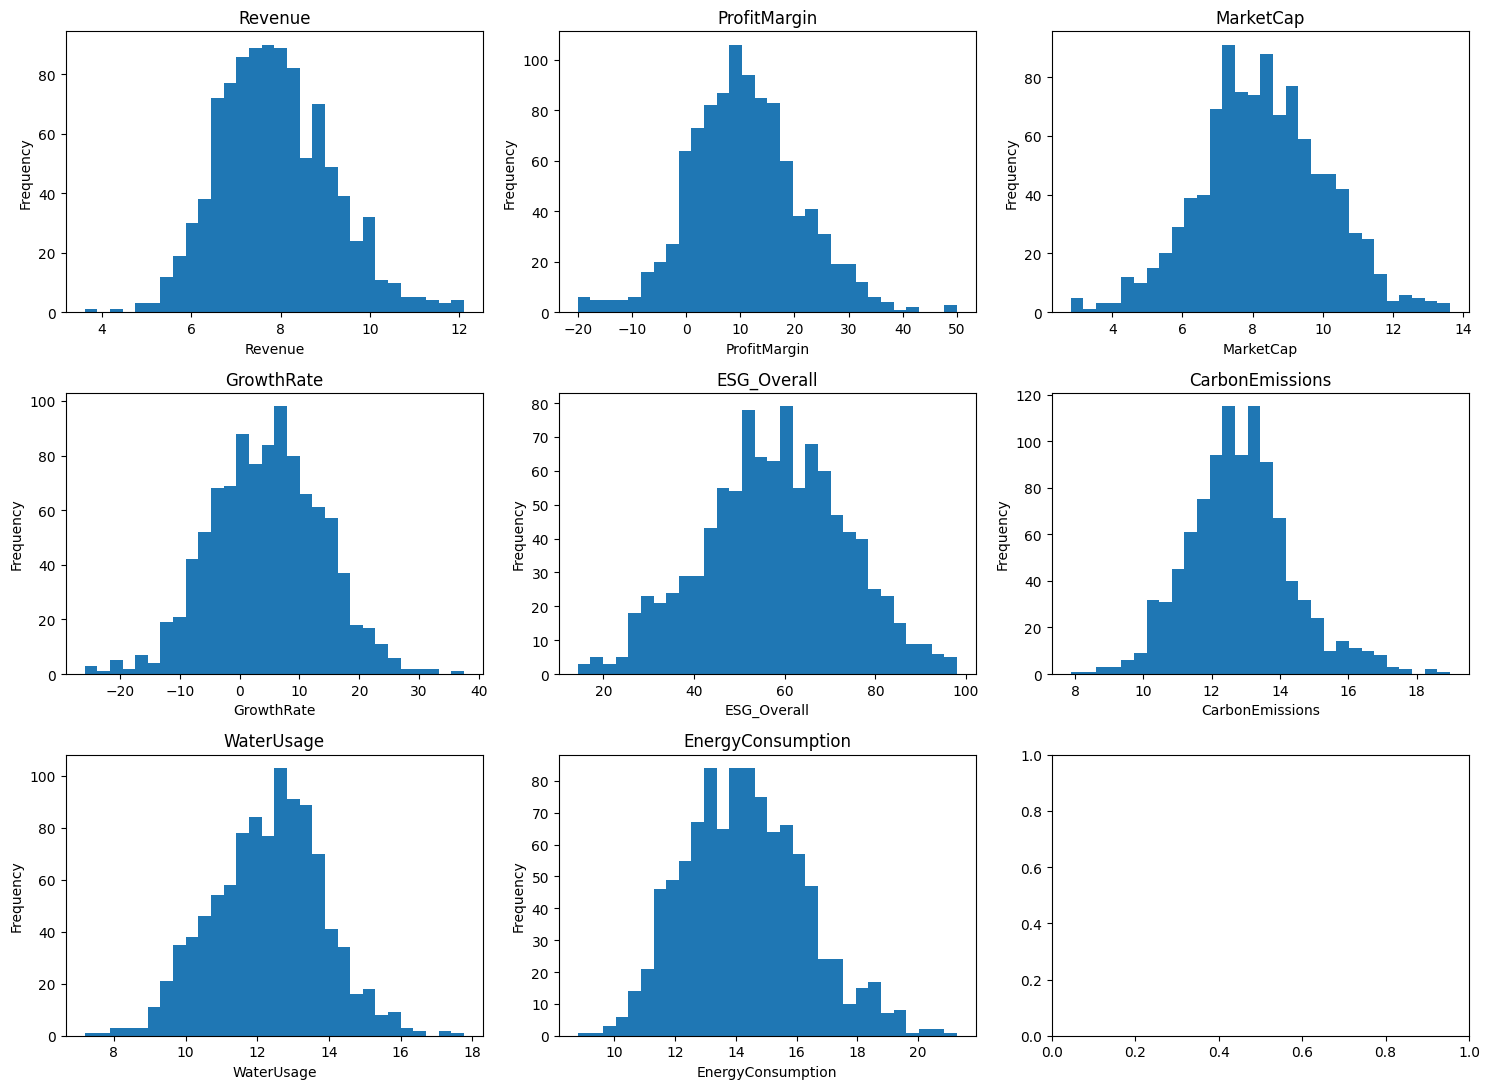

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))

for ax, col in zip(axes.flat, cluster_features):
    ax.hist(model_df[col].dropna(), bins=30)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [11]:
scaler = StandardScaler()
X_cluster = scaler.fit_transform(model_df[cluster_features])

X_cluster = pd.DataFrame(
    X_cluster,
    columns=cluster_features,
    index=model_df.index
)

display(X_cluster.describe().T.round(3))

,count,mean,std,min,25%,50%,75%,max
Revenue,1000.0,-0.0,1.001,-3.397,-0.704,-0.082,0.675,3.358
ProfitMargin,1000.0,-0.0,1.001,-2.999,-0.659,-0.045,0.600,3.824
MarketCap,1000.0,0.0,1.001,-3.063,-0.635,-0.022,0.655,2.968
GrowthRate,1000.0,-0.0,1.001,-3.288,-0.690,0.021,0.692,3.545
ESG_Overall,1000.0,-0.0,1.001,-2.774,-0.674,0.014,0.680,2.560
CarbonEmissions,1000.0,-0.0,1.001,-3.256,-0.637,-0.045,0.551,4.022
WaterUsage,1000.0,0.0,1.001,-3.328,-0.649,0.073,0.677,3.544
EnergyConsumption,1000.0,-0.0,1.001,-2.758,-0.719,-0.045,0.664,3.471


## 4. Model Selection Strategy

We do not assume K-Means is automatically the best clustering algorithm. We compare:

1. **K-Means**
2. **Agglomerative Clustering (Ward linkage)**
3. **Gaussian Mixture Model (GMM)**

For every algorithm, candidate cluster counts \(k=2\ldots8\) are evaluated using:
- **Silhouette Score** — higher is better
- **Calinski-Harabasz Score** — higher is better
- **Davies-Bouldin Score** — lower is better

A **mean metric rank** combines these three metrics. This avoids comparing raw metrics with incompatible scales.

In [12]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture

def evaluate_clustering_model(name, model, X):
    labels = model.fit_predict(X)

    if len(np.unique(labels)) < 2:
        return None

    return {
        "Algorithm": name,
        "k": len(np.unique(labels)),
        "Silhouette": silhouette_score(X, labels),
        "Calinski_Harabasz": calinski_harabasz_score(X, labels),
        "Davies_Bouldin": davies_bouldin_score(X, labels)
    }

cluster_results = []

for k in range(2, 9):
    candidates = {
        "K-Means": KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE),
        "Agglomerative": AgglomerativeClustering(
            n_clusters=k, linkage="ward"
        ),
        "Gaussian Mixture": GaussianMixture(
            n_components=k, random_state=RANDOM_STATE
        )
    }

    for name, model in candidates.items():
        cluster_results.append(
            evaluate_clustering_model(name, model, X_cluster)
        )

cluster_comparison = pd.DataFrame(cluster_results)

cluster_comparison["Silhouette_Rank"] = cluster_comparison["Silhouette"].rank(
    ascending=False, method="average"
)
cluster_comparison["CH_Rank"] = cluster_comparison["Calinski_Harabasz"].rank(
    ascending=False, method="average"
)
cluster_comparison["DB_Rank"] = cluster_comparison["Davies_Bouldin"].rank(
    ascending=True, method="average"
)

cluster_comparison["Mean_Rank"] = cluster_comparison[
    ["Silhouette_Rank", "CH_Rank", "DB_Rank"]
].mean(axis=1)

display(cluster_comparison.sort_values("Mean_Rank").round(4))

,Algorithm,k,Silhouette,Calinski_Harabasz,Davies_Bouldin,Silhouette_Rank,CH_Rank,DB_Rank,Mean_Rank
6,K-Means,4,0.2046,281.8785,1.4064,3.0,4.0,1.0,2.6667
0,K-Means,2,0.2228,356.1610,1.5876,1.0,1.0,7.0,3.0000
3,K-Means,3,0.1905,296.8985,1.5534,4.0,3.0,3.0,3.3333
1,Agglomerative,2,0.2099,303.1428,1.6565,2.0,2.0,9.0,4.3333
12,K-Means,6,0.1691,228.9530,1.5574,6.0,6.0,4.0,5.3333
9,K-Means,5,0.1747,250.4782,1.5847,5.0,5.0,6.0,5.3333
15,K-Means,7,0.1658,210.8142,1.5346,7.0,8.0,2.0,5.6667
18,K-Means,8,0.1548,197.7350,1.5654,8.0,9.0,5.0,7.3333
13,Agglomerative,6,0.1172,176.9157,1.6162,10.0,12.0,8.0,10.0000
10,Agglomerative,5,0.1172,185.9113,1.8078,9.0,11.0,13.0,11.0000


### Best configuration for each clustering algorithm

In [13]:
best_by_algorithm = (
    cluster_comparison
    .sort_values("Mean_Rank")
    .groupby("Algorithm", as_index=False)
    .first()
    .sort_values("Mean_Rank")
)

display(best_by_algorithm.round(4))

,Algorithm,k,Silhouette,Calinski_Harabasz,Davies_Bouldin,Silhouette_Rank,CH_Rank,DB_Rank,Mean_Rank
2,K-Means,4,0.2046,281.8785,1.4064,3.0,4.0,1.0,2.6667
0,Agglomerative,2,0.2099,303.1428,1.6565,2.0,2.0,9.0,4.3333
1,Gaussian Mixture,3,0.1010,155.0717,2.1994,16.0,14.0,15.0,15.0000


In [14]:
best_clustering_row = cluster_comparison.sort_values(
    ["Mean_Rank", "Silhouette"],
    ascending=[True, False]
).iloc[0]

BEST_CLUSTERING_ALGORITHM = best_clustering_row["Algorithm"]
N_CLUSTERS = int(best_clustering_row["k"])

print("Best clustering configuration")
print("--------------------------------")
print("Algorithm:", BEST_CLUSTERING_ALGORITHM)
print("k:", N_CLUSTERS)
print("Silhouette:", round(best_clustering_row["Silhouette"], 4))
print("Calinski-Harabasz:", round(best_clustering_row["Calinski_Harabasz"], 4))
print("Davies-Bouldin:", round(best_clustering_row["Davies_Bouldin"], 4))
print("Mean metric rank:", round(best_clustering_row["Mean_Rank"], 4))

Best clustering configuration
--------------------------------
Algorithm: K-Means
k: 4
Silhouette: 0.2046
Calinski-Harabasz: 281.8785
Davies-Bouldin: 1.4064
Mean metric rank: 2.6667


### Fit the selected clustering model

The selected model is fitted below and its cluster labels are used as the target for the supervised stage.

In [15]:
if BEST_CLUSTERING_ALGORITHM == "K-Means":
    best_cluster_model = KMeans(
        n_clusters=N_CLUSTERS,
        n_init=20,
        random_state=RANDOM_STATE
    )
elif BEST_CLUSTERING_ALGORITHM == "Agglomerative":
    best_cluster_model = AgglomerativeClustering(
        n_clusters=N_CLUSTERS,
        linkage="ward"
    )
else:
    best_cluster_model = GaussianMixture(
        n_components=N_CLUSTERS,
        random_state=RANDOM_STATE
    )

best_cluster_labels = best_cluster_model.fit_predict(X_cluster)
model_df["Cluster"] = best_cluster_labels

print("Selected clustering model:", BEST_CLUSTERING_ALGORITHM)
print("Selected k:", N_CLUSTERS)
print("Silhouette:", round(
    silhouette_score(X_cluster, best_cluster_labels), 4
))

display(
    model_df["Cluster"]
    .value_counts()
    .sort_index()
    .rename("count")
    .to_frame()
)

Selected clustering model: K-Means
Selected k: 4
Silhouette: 0.2046


,count
Cluster,
0,257
1,145
2,218
3,380


## 5. Visualize the Selected Segmentation

PCA explained variance: [0.439  0.2311] | Total: 0.6701


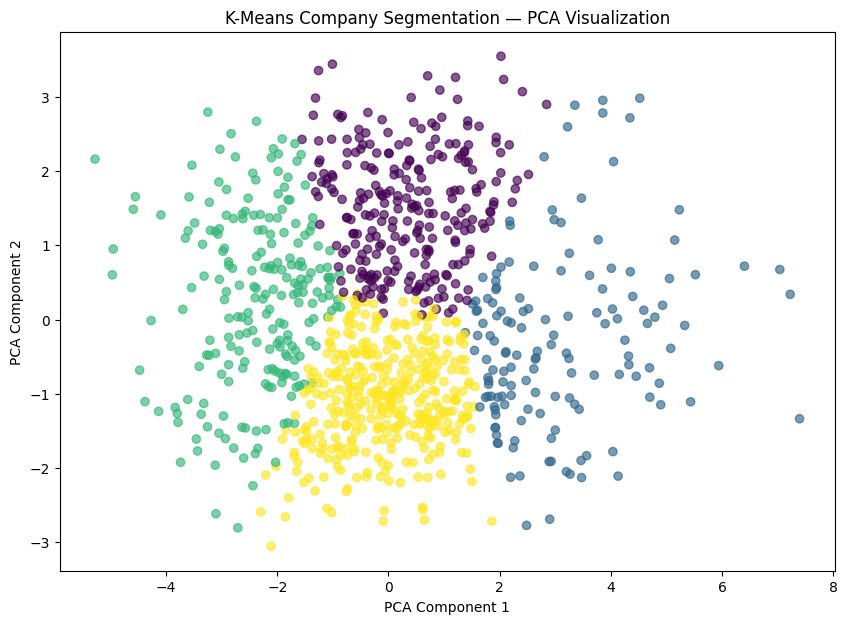

In [16]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_cluster)

model_df["PCA1"] = X_pca[:, 0]
model_df["PCA2"] = X_pca[:, 1]

print(
    "PCA explained variance:",
    np.round(pca.explained_variance_ratio_, 4),
    "| Total:",
    round(pca.explained_variance_ratio_.sum(), 4)
)

plt.figure(figsize=(10, 7))
plt.scatter(
    model_df["PCA1"],
    model_df["PCA2"],
    c=model_df["Cluster"],
    alpha=0.65
)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title(
    f"{BEST_CLUSTERING_ALGORITHM} Company Segmentation — PCA Visualization"
)
plt.show()

## 6. Cluster Profiling

Cluster numbers are arbitrary. Persona names are **post-hoc business interpretations**, not ground-truth labels.

,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,CarbonEmissions,WaterUsage,EnergyConsumption
Cluster,,,,,,,,
0,8.83,17.81,9.91,7.94,64.85,12.52,12.18,13.39
1,9.33,11.52,9.95,9.41,53.04,15.28,14.61,17.30
2,6.90,8.85,7.10,1.61,61.49,11.03,10.36,11.99
3,7.25,6.81,7.28,2.23,52.82,13.17,12.64,15.14


,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,CarbonEmissions,WaterUsage,EnergyConsumption
Cluster,,,,,,,,
0,0.75,0.69,0.90,0.36,0.45,-0.21,-0.08,-0.46
1,1.16,0.07,0.92,0.52,-0.31,1.60,1.49,1.49
2,-0.78,-0.19,-0.67,-0.32,0.23,-1.19,-1.27,-1.16
3,-0.50,-0.39,-0.57,-0.26,-0.32,0.21,0.22,0.41


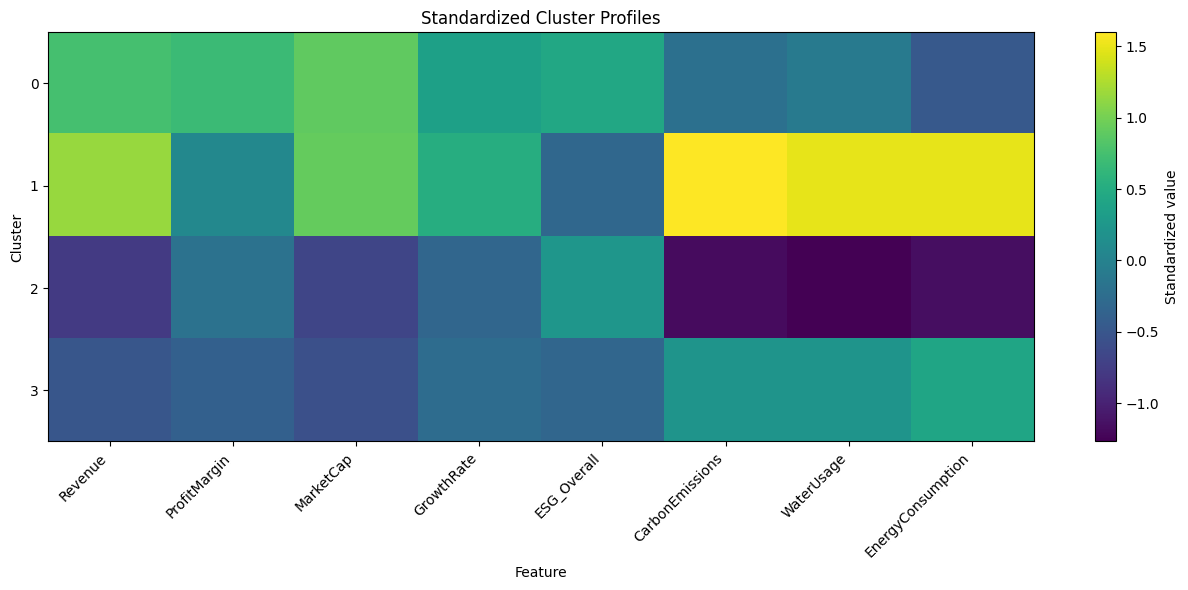

In [17]:
profile_features = cluster_features

cluster_profile = model_df.groupby("Cluster")[profile_features].mean()
display(cluster_profile.round(2))

if BEST_CLUSTERING_ALGORITHM in ["K-Means", "Gaussian Mixture"]:
    centers = (
        best_cluster_model.cluster_centers_
        if BEST_CLUSTERING_ALGORITHM == "K-Means"
        else best_cluster_model.means_
    )

    centroid_profile = pd.DataFrame(
        centers, columns=cluster_features
    )
    centroid_profile.index.name = "Cluster"

    display(centroid_profile.round(2))

    plt.figure(figsize=(13, 6))
    plt.imshow(centroid_profile.values, aspect="auto")
    plt.xticks(range(len(cluster_features)), cluster_features, rotation=45, ha="right")
    plt.yticks(range(len(centroid_profile)), centroid_profile.index)
    plt.xlabel("Feature")
    plt.ylabel("Cluster")
    plt.title("Standardized Cluster Profiles")
    plt.colorbar(label="Standardized value")
    plt.tight_layout()
    plt.show()

In [18]:
cluster_names = {
    0: "High-Performance Innovators",
    1: "Resource Intensive Giants",
    2: "Sustainable Service Firms",
    3: "Traditional Operators"
}

model_df["Persona"] = model_df["Cluster"].map(cluster_names)

persona_summary = (
    model_df.groupby("Persona")[profile_features]
    .mean()
    .sort_values("ESG_Overall", ascending=False)
)

display(persona_summary.round(2))

,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,CarbonEmissions,WaterUsage,EnergyConsumption
Persona,,,,,,,,
High-Performance Innovators,8.83,17.81,9.91,7.94,64.85,12.52,12.18,13.39
Sustainable Service Firms,6.90,8.85,7.10,1.61,61.49,11.03,10.36,11.99
Resource Intensive Giants,9.33,11.52,9.95,9.41,53.04,15.28,14.61,17.30
Traditional Operators,7.25,6.81,7.28,2.23,52.82,13.17,12.64,15.14


## 7. Supervised Classification Model Comparison

The target is the cluster label produced by the selected clustering model.

This is a **surrogate classification task**: the classifier learns to reproduce the unsupervised segmentation.

In [19]:
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)
from sklearn.svm import SVC

X_supervised = X_cluster.copy()
y = model_df["Cluster"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X_supervised,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

classification_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=3000,
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        random_state=RANDOM_STATE,
        class_weight="balanced"
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=400,
        random_state=RANDOM_STATE,
        class_weight="balanced"
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),
    "SVM (RBF)": SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale"
    )
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

classification_rows = []

for name, model in classification_models.items():
    scores = cross_validate(
        model,
        X_supervised,
        y,
        cv=cv,
        scoring=[
            "accuracy",
            "f1_weighted",
            "precision_weighted",
            "recall_weighted"
        ]
    )

    classification_rows.append({
        "Model": name,
        "CV Accuracy Mean": scores["test_accuracy"].mean(),
        "CV Accuracy Std": scores["test_accuracy"].std(),
        "CV F1 Weighted": scores["test_f1_weighted"].mean(),
        "CV Precision Weighted": scores["test_precision_weighted"].mean(),
        "CV Recall Weighted": scores["test_recall_weighted"].mean()
    })

classification_comparison = (
    pd.DataFrame(classification_rows)
    .sort_values(
        ["CV F1 Weighted", "CV Accuracy Mean"],
        ascending=False
    )
    .reset_index(drop=True)
)

display(classification_comparison.round(4))

,Model,CV Accuracy Mean,CV Accuracy Std,CV F1 Weighted,CV Precision Weighted,CV Recall Weighted
0,Logistic Regression,0.978,0.0040,0.9780,0.9783,0.978
1,SVM (RBF),0.958,0.0098,0.9579,0.9591,0.958
2,Extra Trees,0.942,0.0175,0.9417,0.9439,0.942
3,HistGradientBoosting,0.934,0.0166,0.9340,0.9359,0.934
4,Gradient Boosting,0.927,0.0232,0.9268,0.9298,0.927
5,Random Forest,0.924,0.0318,0.9236,0.9266,0.924


### Select the best classifier

In [20]:
best_classifier_name = classification_comparison.iloc[0]["Model"]
best_classifier = classification_models[best_classifier_name]

best_classifier.fit(X_train, y_train)
best_pred = best_classifier.predict(X_test)

print("Best classifier:", best_classifier_name)
print("Test accuracy:", round(accuracy_score(y_test, best_pred), 4))
print(
    "Test weighted F1:",
    round(f1_score(y_test, best_pred, average="weighted"), 4)
)
print(
    "Test weighted precision:",
    round(precision_score(y_test, best_pred, average="weighted"), 4)
)
print(
    "Test weighted recall:",
    round(recall_score(y_test, best_pred, average="weighted"), 4)
)

print("\nClassification Report:\n")
print(classification_report(y_test, best_pred))

Best classifier: Logistic Regression
Test accuracy: 0.98
Test weighted F1: 0.98
Test weighted precision: 0.9801
Test weighted recall: 0.98

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        51
           1       0.97      0.97      0.97        29
           2       1.00      0.98      0.99        44
           3       0.97      0.99      0.98        76

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200



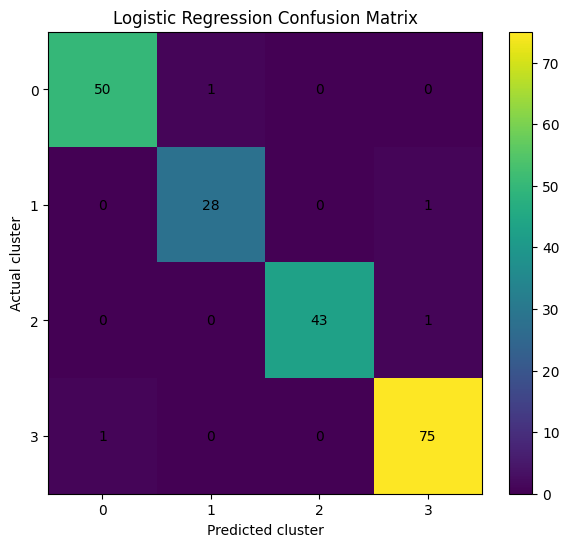

In [21]:
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(7, 6))
plt.imshow(cm, aspect="auto")
plt.colorbar()
plt.xticks(range(len(np.unique(y))), sorted(y.unique()))
plt.yticks(range(len(np.unique(y))), sorted(y.unique()))
plt.xlabel("Predicted cluster")
plt.ylabel("Actual cluster")
plt.title(f"{best_classifier_name} Confusion Matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

## 8. Feature Importance / Model Interpretation

In [22]:
if hasattr(best_classifier, "feature_importances_"):
    feature_importance = (
        pd.Series(
            best_classifier.feature_importances_,
            index=cluster_features
        )
        .sort_values(ascending=False)
        .to_frame("Importance")
    )
    display(feature_importance)

perm = permutation_importance(
    best_classifier,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="accuracy"
)

perm_importance = (
    pd.DataFrame({
        "Feature": cluster_features,
        "Importance_Mean": perm.importances_mean,
        "Importance_STD": perm.importances_std
    })
    .sort_values("Importance_Mean", ascending=False)
)

display(perm_importance)

,Feature,Importance_Mean,Importance_STD
7,EnergyConsumption,0.169,0.029816
0,Revenue,0.142,0.014526
2,MarketCap,0.138,0.019647
5,CarbonEmissions,0.109,0.015133
6,WaterUsage,0.108,0.016000
1,ProfitMargin,0.061,0.014457
4,ESG_Overall,0.053,0.010296
3,GrowthRate,0.052,0.012288


## 9. New Company Prediction

In [23]:
def preprocess_new_company(new_data):
    new_data = new_data.copy()

    for col in log_features:
        new_data[col] = np.log1p(new_data[col])

    return scaler.transform(new_data[cluster_features])


def predict_persona(new_data):
    X_new = preprocess_new_company(new_data)

    cluster_id = int(best_cluster_model.predict(X_new)[0])
    classifier_id = int(best_classifier.predict(X_new)[0])

    return {
        "Clustering_Model": BEST_CLUSTERING_ALGORITHM,
        "Selected_Cluster": cluster_id,
        "Selected_Cluster_Persona": cluster_names.get(
            cluster_id, f"Cluster {cluster_id}"
        ),
        "Classifier_Model": best_classifier_name,
        "Classifier_Cluster": classifier_id,
        "Classifier_Persona": cluster_names.get(
            classifier_id, f"Cluster {classifier_id}"
        )
    }

example_company = company_df[cluster_features].iloc[[0]].copy()
display(pd.DataFrame([predict_persona(example_company)]))

,Clustering_Model,Selected_Cluster,Selected_Cluster_Persona,Classifier_Model,Classifier_Cluster,Classifier_Persona
0,K-Means,2,Sustainable Service Firms,Logistic Regression,2,Sustainable Service Firms


## 10. Serialize the Best Production Artifacts

In [24]:
import joblib
from pathlib import Path

artifacts = {
    "cluster_features": cluster_features,
    "log_features": log_features,
    "scaler": scaler,
    "clustering_algorithm": BEST_CLUSTERING_ALGORITHM,
    "n_clusters": N_CLUSTERS,
    "clustering_model": best_cluster_model,
    "classifier_name": best_classifier_name,
    "classifier": best_classifier,
    "cluster_names": cluster_names,
    "pca": pca,
    "cluster_comparison": cluster_comparison,
    "classification_comparison": classification_comparison
}

ARTIFACT_PATH = Path("/tmp/esg_company_segmentation_best_models.joblib")
joblib.dump(artifacts, ARTIFACT_PATH)

print("Saved:", ARTIFACT_PATH)
print("Artifact size (bytes):", ARTIFACT_PATH.stat().st_size)

Saved: /tmp/esg_company_segmentation_best_models.joblib
Artifact size (bytes): 12920


## 11. Final Model Selection — Interview Summary

**Clustering:** K-Means, Agglomerative Clustering and Gaussian Mixture Models were compared using three internal validation metrics. The final clustering model is selected by combined metric ranking.

**Classification:** Logistic Regression, Random Forest, Extra Trees, Gradient Boosting, HistGradientBoosting and SVM were compared using stratified 5-fold cross-validation. The classifier with the strongest weighted F1 is selected.

**Important:** The classifier predicts labels created by clustering, so classification performance measures the reproducibility of the segmentation rather than external ground-truth accuracy.